Unzipping archive (21).zip...
Unzipping complete.
Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Classes: ['no', 'yes']
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5813 - loss: 0.8318 - val_accuracy: 0.8000 - val_loss: 0.5614
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 862ms/step - accuracy: 0.7537 - loss: 0.5377 - val_accuracy: 0.7800 - val_loss: 0.5779
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7833 - loss: 0.4870 - val_accuracy: 0.7800 - val_loss: 0.5313
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 855ms/step - accuracy: 0.8030 - loss: 0.4559 - val_accuracy: 0.8000 - val_loss: 0.5313
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8227 - loss: 0.4035 - val_accuracy: 0.8000 - val_loss: 0.5750
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8522 - loss: 0.3543 - val_accuracy: 0.8200 - val_loss: 0.5262
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 854ms/step - accuracy: 0.8916 - loss: 0.2848 - val_accuracy: 0.8400 - val_loss: 0.6270
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 847ms/step - accuracy: 0.8768 - loss: 0.2823 - val_accuracy: 0.8400 - val_loss: 0.5076
Epoch 9/10
7

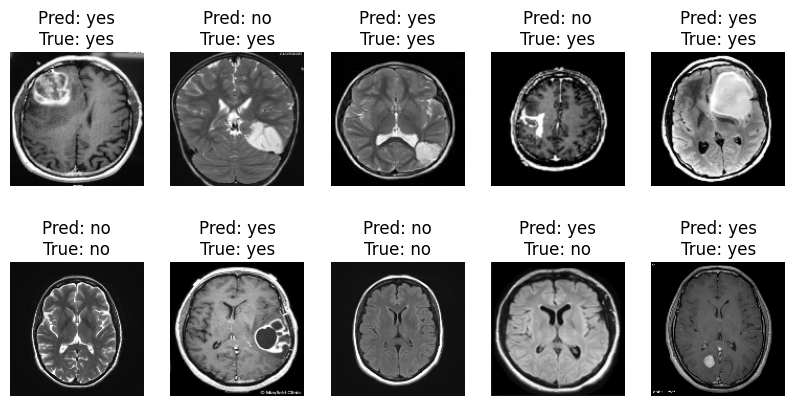

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

# Dataset path
dataset_path = "brain_tumor_dataset"
zip_file_path = "archive (21).zip"

# Check if the dataset directory exists, if not, try to extract it
if not os.path.exists(dataset_path):
    if os.path.exists(zip_file_path):
        print(f"Unzipping {zip_file_path}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(".") # Extract to the current directory
        print("Unzipping complete.")
    else:
        print(f"Error: Dataset directory '{dataset_path}' and zip file '{zip_file_path}' not found.")
        print("Please upload the 'brain_tumor_dataset' folder or the 'archive (21).zip' file.")

# Load images from folders
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# CNN Model
model = keras.Sequential([

    keras.layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(len(class_names), activation='softmax') # Changed to len(class_names) and softmax for multi-class classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Changed loss function for multi-class classification
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate
loss, acc = model.evaluate(val_ds)

print(f"\nValidation Accuracy: {acc:.4f}")

# Prediction on a few images
for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(10,5))

    for i in range(10):

        plt.subplot(2,5,i+1)
        plt.imshow(images[i].numpy())
        # Display predicted class name
        predicted_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i].numpy()]
        plt.title(f"Pred: {predicted_class}\nTrue: {true_class}")
        plt.axis("off")

    plt.show()

### Upload and Predict on a New Image

Use the cell below to upload an image from your local machine. The model will then predict whether it contains a tumor.

In [ ]:
from google.colab import files
from PIL import Image

# Upload a file
uploaded = files.upload()

# Get the filename of the uploaded image
for fn in uploaded.keys():
    uploaded_image_path = fn

# Load and preprocess the uploaded image
img = Image.open(uploaded_image_path).resize((128, 128))
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch

# Normalize the image (as done for training and validation data)
img_array = normalization_layer(img_array)

print(f"Uploaded image '{uploaded_image_path}' processed for prediction.")

Saving 3c7b18a8-c266-455c-b552-dd660d9fac50.jpg to 3c7b18a8-c266-455c-b552-dd660d9fac50.jpg
Uploaded image '3c7b18a8-c266-455c-b552-dd660d9fac50.jpg' processed for prediction.


### Make Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


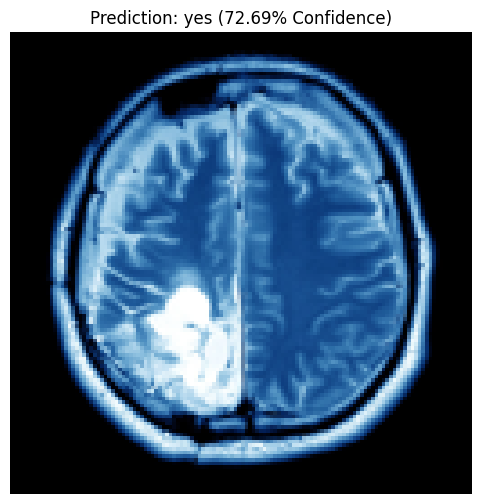

This image most likely belongs to yes with a 72.69% confidence.


In [ ]:
# Make prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

predicted_class_index = np.argmax(score)
predicted_class_name = class_names[predicted_class_index]
confidence = 100 * np.max(score)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}% Confidence)")
plt.axis("off")
plt.show()

print(f"This image most likely belongs to {predicted_class_name} with a {confidence:.2f}% confidence.")